In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [ ]:
# Base dataset
df = pd.read_csv("../../Data/Processed/renttherunway_clean.csv")

# GMM clusters
gmm = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")[["user_id", "item_id", "body_cluster", "cluster_confidence"]]

# DBSCAN clusters
dbscan = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")[["user_id", "dbscan_cluster"]]

# K-Means clusters
kmeans = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv").rename(columns={"cluster": "kmeans_cluster"})

# LDA topic features
lda = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")

In [42]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [43]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [44]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [45]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [46]:
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [47]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [48]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [49]:
assert y.notna().all()

In [50]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [51]:
from sklearn.decomposition import PCA

preprocessor = ColumnTransformer(
    transformers=[
        # --- Body measurements: PCA applied ---
        (
            "num_pca",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=0.95, random_state=42))
            ]),
            NUMERIC_FEATURES
        ),

        # --- Topic distributions: NO PCA ---
        (
            "topics",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            TOPIC_FEATURES
        ),

        # --- Cluster features (categorical) ---
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # --- Binary features ---
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop",
    sparse_threshold=0.0
)

In [52]:
svm = SVC(
    kernel="rbf",
    probability=True,      # REQUIRED for predict_proba
    class_weight="balanced",
    random_state=42
)

In [53]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", svm)
])

In [54]:
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.1]
}

In [55]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [56]:
from sklearn.model_selection import StratifiedShuffleSplit

N_SVM = 30_000

sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=N_SVM,
    random_state=42
)

for idx, _ in sss.split(X_train_full, y_train_full):
    X_train_svm = X_train_full.iloc[idx]
    y_train_svm = y_train_full.iloc[idx]

In [57]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train_svm, y_train_svm)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ....................model__C=10, model__gamma=scale; total time= 2.5min
[CV] END .......................model__C=1, model__gamma=0.1; total time= 2.9min
[CV] END .....................model__C=1, model__gamma=scale; total time= 2.9min
[CV] END .....................model__C=1, model__gamma=scale; total time= 3.0min
[CV] END ...................model__C=0.1, model__gamma=scale; total time= 3.2min
[CV] END .......................model__C=1, model__gamma=0.1; total time= 3.7min
[CV] END ....................model__C=10, model__gamma=scale; total time= 3.7min
[CV] END .......................model__C=1, model__gamma=0.1; total time= 3.8min
[CV] END .....................model__C=1, model__gamma=scale; total time= 4.0min
[CV] END .....................model__C=0.1, model__gamma=0.1; total time= 4.3min
[CV] END ....................model__C=10, model__gamma=scale; total time= 1.7min
[CV] END ...................model__C=0.1, model__

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 1, ...], 'model__gamma': ['scale', 0.1]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [58]:
best_svm = grid.best_estimator_

y_test_pred = best_svm.predict(X_test)

print("Best Kernel SVM parameters:")
print(grid.best_params_)

print("\nKernel SVM — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best Kernel SVM parameters:
{'model__C': 10, 'model__gamma': 0.1}

Kernel SVM — Test Set Performance
              precision    recall  f1-score   support

       Small       0.59      0.63      0.61     34494
         Fit       0.88      0.88      0.88    174054
       Large       0.78      0.75      0.77     57738

    accuracy                           0.82    266286
   macro avg       0.75      0.75      0.75    266286
weighted avg       0.82      0.82      0.82    266286



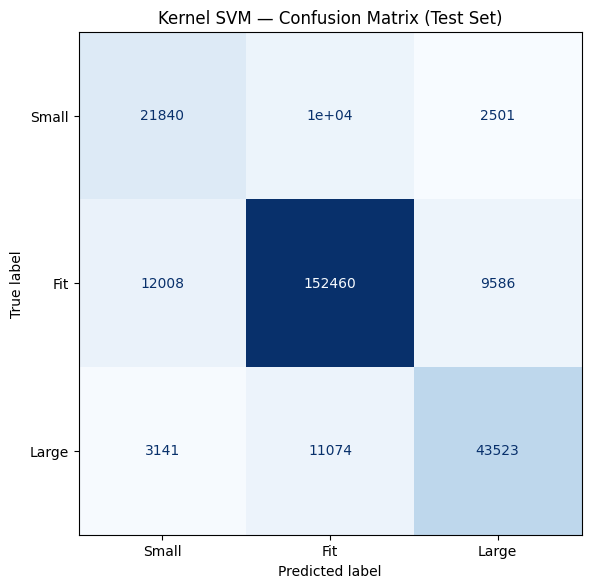

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Kernel SVM — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/kernel_svm_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
svm_proba = best_svm.predict_proba(X_test)

svm_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": svm_proba[:, 0],
    "prob_fit": svm_proba[:, 1],
    "prob_large": svm_proba[:, 2]
})

svm_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/kernel_svm_fit_probabilities.csv",
    index=False
)

In [ ]:
prep = best_svm.named_steps["prep"]

feature_names = []
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
feature_names.extend(
    cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
)

feature_names.extend(BINARY_FEATURES)

pd.Series(feature_names).to_csv(
    "../../Data/Processed/Supervised_Outputs/kernel_svm_feature_names.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    best_svm,
    "../../Models/kernel_svm_fit_classifier.joblib"
)

['../Models/kernel_svm_fit_classifier.joblib']

## Kernel SVM — Model Performance Writeup

### Overview
A Kernel Support Vector Machine was trained on the clothing fit classification task, predicting **Small**, **Fit**, or **Large**. Grid search identified optimal hyperparameters of `C=10` and `gamma=0.1`, using an RBF kernel. Unlike the tree-based methods previously evaluated, SVMs operate by finding maximum-margin decision boundaries in a high-dimensional feature space — a fundamentally different inductive approach that proves notably more effective here.

---

### Overall Performance
The Kernel SVM achieved **82% accuracy** on the 266,286-sample test set, with a weighted F1-score of **0.82**. This marks a meaningful step up from both CART (73%) and the Bagging Classifier (77%), making it the strongest model evaluated so far. Crucially, unlike the tree-based models, precision and recall are well-balanced across all classes — a sign that the model is generalizing more evenly rather than over-relying on the majority class.

---

### Class-Level Analysis

**Fit (Majority Class)**
Excellent and balanced performance at **0.88 precision, 0.88 recall**, and an F1 of **0.88**. This is the highest Fit-class F1 of all three models, and the near-perfect precision-recall symmetry indicates the SVM is not simply defaulting to "Fit" to inflate accuracy. Only 12,008 true Fit items were misclassified as Small — less than half the leakage seen in CART (31,218) and well below Bagging (27,495).

**Large**
Strong performance with **0.78 precision** and **0.75 recall** (F1 = 0.77). Of 57,738 true Large items, 43,523 were correctly identified. The main confusion is with Fit (11,074 misclassified), which remains the hardest boundary to draw across all models, but the SVM handles it better than both tree-based approaches.

**Small (Minority Class)**
The most dramatic improvement over prior models. Precision jumps to **0.59** (vs. 0.43 for Bagging, 0.39 for CART) and F1 reaches **0.61** (vs. 0.56 and 0.51 respectively). The SVM's margin-based learning appears to better carve out the Small class despite its underrepresentation, though recall of 0.63 indicates roughly 1 in 3 true Small items are still missed. This remains the hardest class but is meaningfully more tractable here.

---

### Comparison Across All Three Models

| Metric | CART | Bagging | Kernel SVM |
|---|---|---|---|
| Accuracy | 73% | 77% | **82%** |
| Weighted F1 | 0.74 | 0.79 | **0.82** |
| Small F1 | 0.51 | 0.56 | **0.61** |
| Fit F1 | 0.80 | 0.84 | **0.88** |
| Large F1 | 0.70 | 0.75 | **0.77** |
| Small Precision | 0.39 | 0.43 | **0.59** |

The Kernel SVM leads across every single metric. The improvement is most pronounced for the Small class, where prior models struggled significantly with precision.

---

### Key Takeaways
| Metric | Value |
|---|---|
| Overall Accuracy | 82% |
| Best Class | Fit (F1 = 0.88) |
| Weakest Class | Small (F1 = 0.61, precision = 0.59) |
| Primary Error Mode | Large items predicted as Fit (11,074 cases) |

The Kernel SVM is the clear winner among the three models evaluated. Its ability to construct non-linear decision boundaries via the RBF kernel gives it a structural edge on what appears to be a complex, overlapping feature space. The tradeoff is computational cost — SVMs scale poorly with large datasets, so inference time and training overhead should be weighed against the performance gains in any production deployment. That said, for a fit recommendation system where misprediction carries real user experience costs, the added accuracy is likely worth the investment.